In [1]:
using Distributions
using Plots
using StatsPlots
using Turing

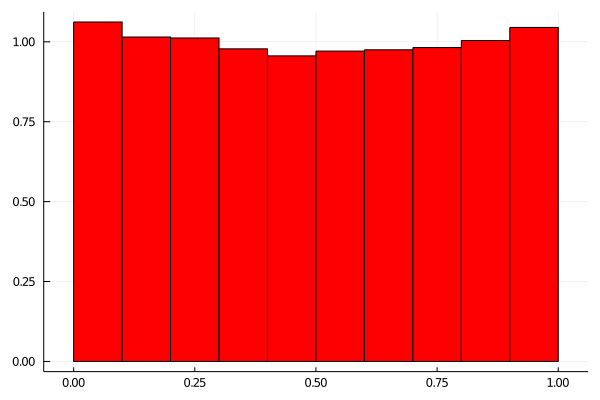

In [2]:
n = 10000
p_priorvals = rand(Uniform(0, 1), n)

plot(p_priorvals, 
     seriestype=:histogram, 
     normalize=true, 
     bins=10, 
     legend=false, 
     color="red")

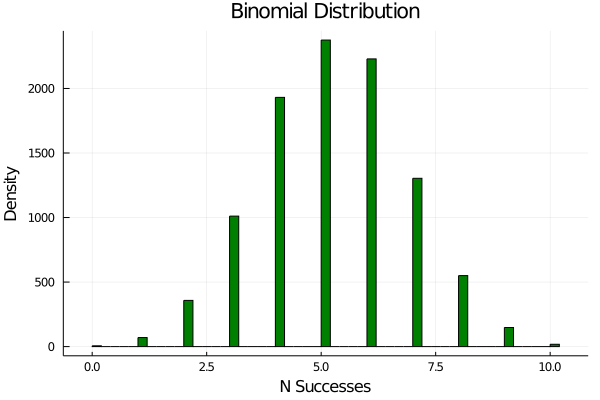

In [3]:
N = 10
p = 0.52
plot(rand(Binomial(N, p), n), 
     seriestype=:histogram,
     label=false, 
     xlabel="N Successes", 
     ylabel="Density", 
     title="Binomial Distribution", 
     color="green")

In [4]:
rand(Binomial(20, 0.5), 3)

3-element Array{Int64,1}:
  9
 12
  8

In [5]:
@model coinflip(y) = begin
    # Prior heads prob (no info) 
    p ~ Uniform(0, 1)
    N = length(y) # observations
    for n in 1:N
        y[n] ~ Bernoulli(p)
    end
end

coinflip (generic function with 1 method)

In [6]:
outcome = [0, 1, 1, 0, 1, 0, 0, 1, 1, 1]

10-element Array{Int64,1}:
 0
 1
 1
 0
 1
 0
 0
 1
 1
 1

In [7]:
iterations = 1000
eps = 0.05 # ?
tau = 10   # ?
chain = sample(coinflip(outcome[1]), HMC(eps, tau), iterations)

Chains MCMC chain (1000×10×1 Array{Float64,3}):

Iterations        = 1:1000
Thinning interval = 1
Chains            = 1
Samples per chain = 1000
parameters        = p
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size

Summary Statistics
  parameters      mean       std   naive_se      mcse       ess      rhat 
      Symbol   Float64   Float64    Float64   Float64   Float64   Float64 

           p    0.3112    0.2385     0.0075    0.0469   20.9741    1.0022

Quantiles
  parameters      2.5%     25.0%     50.0%     75.0%     97.5% 
      Symbol   Float64   Float64   Float64   Float64   Float64 

           p    0.0008    0.1147    0.2752    0.4769    0.8318


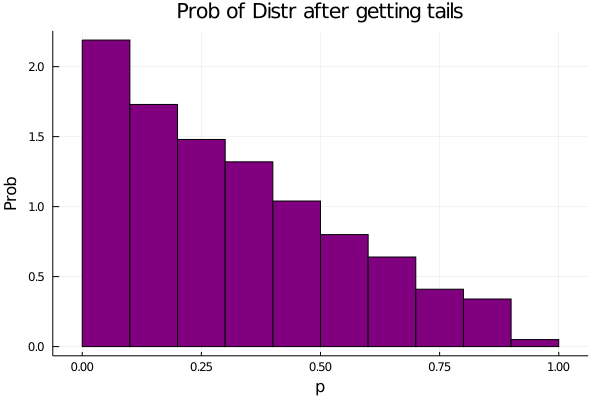

In [8]:
psummary = chain[:p]
plot(psummary, 
     seriestype=:histogram, 
     normed=true, 
     legend=false, 
     color="purple",
     xlabel="p",
     ylabel="Prob",
     title="Prob of Distr after getting tails")

In [9]:
samples = []
for i in 2:10
    global chain_
    chain_ = sample(coinflip(outcome[1:i]), HMC(eps, tau), iterations)
    push!(samples, chain_)
end

Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00


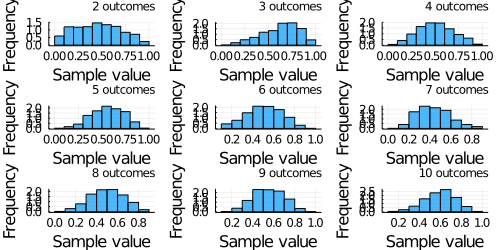

In [10]:
plots = histogram.(samples, normalized=true, legend=false, bins=10)
p_ = plot(plots..., 
          layout=9, 
          title=["$i outcomes" for j in 1:1, i in 2:10], 
          titleloc=:right, 
          titlefont=font(8))

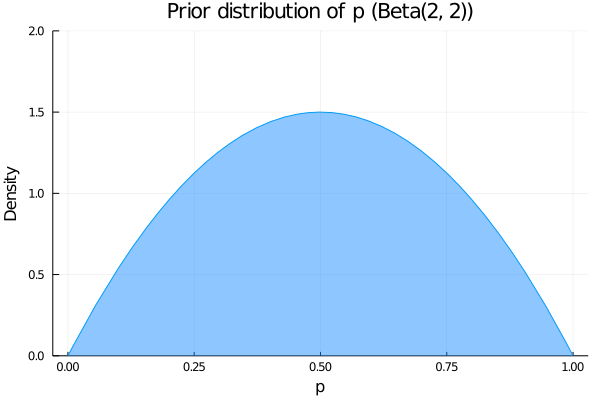

In [11]:
# use a beta prior to show assumption that p is likely CLOSE to 0.5
plot(Beta(2, 2), fill=(0, 0.5, :dodgerblue), ylim=(0, 2), legend=false)
xlabel!("p")
ylabel!("Density")
title!("Prior distribution of p (Beta(2, 2))")

In [12]:
@model coinflip_betaprior(y) = begin
    p ~ Beta(2, 2)
    N = length(y)
    for n in 1:N
        y[n] ~ Bernoulli(p)
    end
end

coinflip_betaprior (generic function with 1 method)

In [14]:
samples_betaprior = []
for i in 2:10
    global chain__
    chain__ = sample(
        coinflip_betaprior(outcome[1:i]), HMC(eps, tau), iterations)
    push!(samples_betaprior, chain__[:p])
end

Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00


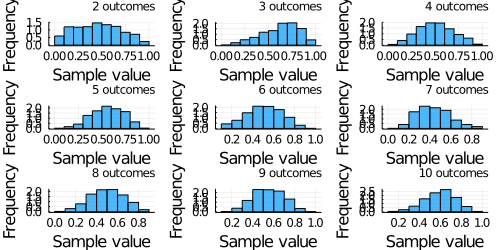

In [15]:
plots_ = histogram.(
    samples_betaprior, normalized=true, legend=false, bins=10, color="red"
)
p__ = plot(plots..., 
           layout=9, 
           title=["$i outcomes" for j in 1:1, i in 2:10], 
           titleloc=:right, 
           titlefont=font(8))

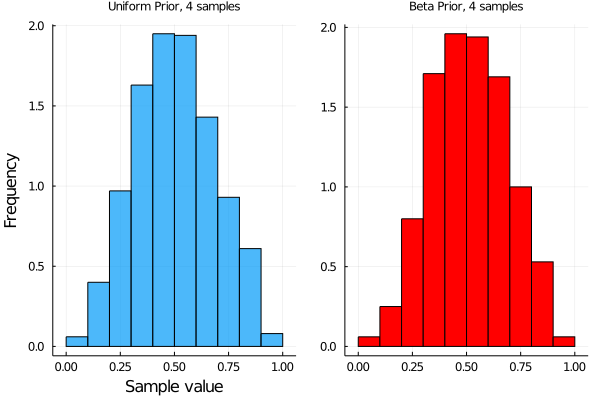

In [16]:
plot(plots[3], 
     plots_[3], 
     title=["Uniform Prior, 4 samples" "Beta Prior, 4 samples"],
     titleloc=:center,
     titlefont=font(8),
     layout=2)

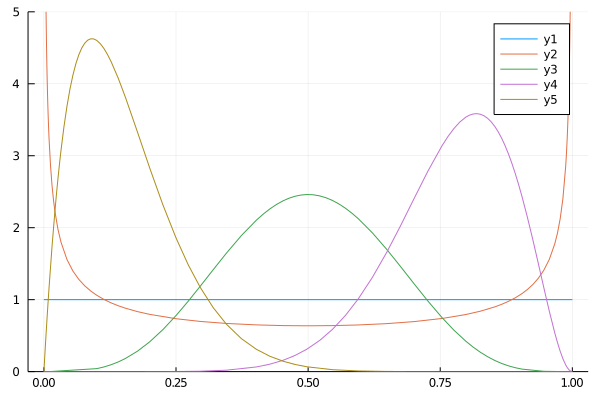

In [18]:
plot(Beta(1, 1), ylim=(0, 5))
plot!(Beta(0.5, 0.5))
plot!(Beta(5, 5))
plot!(Beta(10, 3))
plot!(Beta(2, 11))

In [20]:
mutable struct betabandit
    p::Float64
    a::Int64 # Beta param (n success)
    b::Int64 #            (  fails)
    n::Int64 # no. trials
    betabandit(p=p, a=1, b=1, n=0) = new(p, a, b, n)
end

In [32]:
pullarm(bandit::betabandit) = bandit.p > rand()

pullarm (generic function with 1 method)

In [22]:
samplebandit(bandit::betabandit) = rand(Beta(bandit.a, bandit.b))

samplebandit (generic function with 1 method)

In [23]:
function updatebandit(bandit::betabandit, outcome::Bool)
    outcome ? bandit.a += 1 : bandit.b += 1
    bandit.n += 1
end

updatebandit (generic function with 1 method)

In [24]:
NTRIALS = 100
BANDITPAYOFF_PS = [0.3, 0.5, 0.75]

3-element Array{Float64,1}:
 0.3
 0.5
 0.75

In [33]:
function betabandit_sim(banditprobs, trials)
    bandits = [betabandit(p) for p in banditprobs]
    reward = 0
    for i in 1:trials
        _, mxidx = findmax([rand(Beta(bandit.a, bandit.b)) 
                            for bandit in bandits])
        bestbandit = bandits[mxidx]
        exp = pullarm(bestbandit)
        if exp
            reward += 1
        end
        updatebandit(bestbandit, exp)
    end
    plot()
    for i in 1:length(bandits)
        display(
            plot!(Beta(bandits[i].a, bandits[i].b), 
                  xlim=(0, 1), 
                  lw=2, 
                  xlabel="P(Payout)", 
                  ylabel="Density"))
    end
    return reward, current()
end

betabandit_sim (generic function with 1 method)

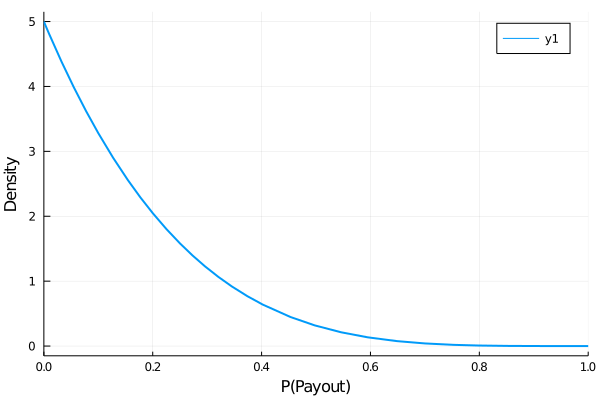

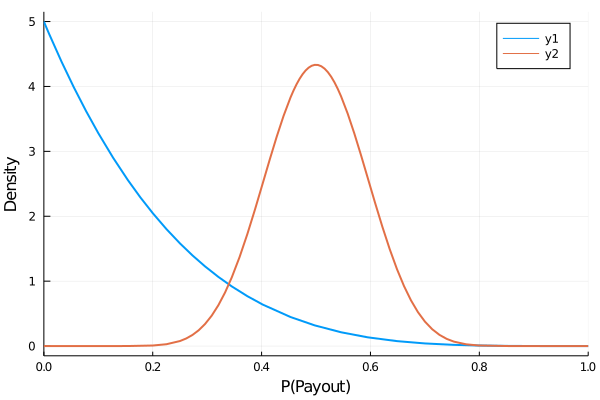

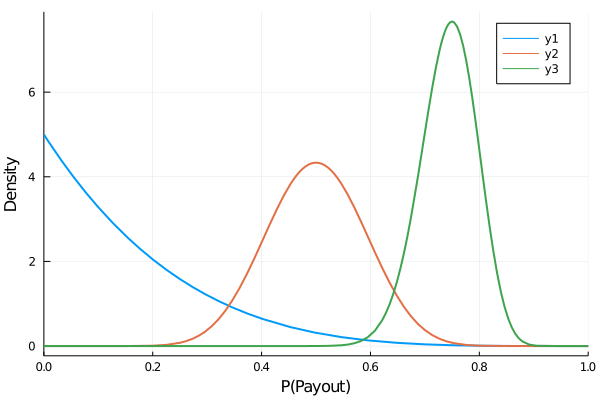

(65, Plot{Plots.GRBackend() n=3})

In [34]:
reward, banditplot = betabandit_sim(BANDITPAYOFF_PS, NTRIALS)